# Best practices for spatial proteomics with MINA

Spatial-proteomics platforms (MIBI, IMC, CODEX, …) profile a few dozen proteins
across many cells in intact tissue. MINA turns such data into **multicellular
factors** — coordinated programs spanning cell types. This guide collects
practical recommendations for each stage of that workflow.

The runnable cells use the small synthetic object shipped with the docs
(`data/muvicell_synthetic.h5mu`) so the guide executes anywhere; cells that need
real single-cell imaging data are clearly marked as **templates**.

!!! tip "Requirements"
    `pip install "mina[spatial]"` and a working `mofaflex` install.

In [1]:
import numpy as np
import pandas as pd
import mudata as md
import matplotlib.pyplot as plt

import mofaflex as mf
import mina

mdata = md.read("data/muvicell_synthetic.h5mu")
anndata_dict = {view: mdata[view].copy() for view in mdata.mod}
metadata = mdata.obs.copy()
metadata["sample_id"] = metadata.index.astype(str)

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


## 1. Build one view per cell type, samples = images

MINA expects a **dict of per-view `AnnData`** (one per cell type / lineage) plus
a sample-level metadata table. The *samples* are usually patients or fields of
view. Pseudo-bulk per (sample, cell type) before modelling — start from raw
counts/intensities so you can apply consistent normalisation.

**Template** — from a single-cell `AnnData` with a `cell_type` and a `sample`
column:

```python
import decoupler as dc
metadata = mina.up.extract_metadata_from_obs(adata.obs, groupby="sample_id")
pdata = dc.pp.pseudobulk(adata, sample_col="sample_id", groups_col="cell_type", layer="counts")
anndata_dict = mina.up.split_anndata_by_celltype(pdata, grouping="cell_type")
```

## 2. Quality-control the pseudo-bulk

Sparse views and poorly covered samples add noise. Inspect them, then filter.
The order below (drop tiny cell populations → require enough samples per view →
filter low-expressed features → require enough features per view → drop
low-coverage samples → require samples present in enough views) is a robust
default.

**Template** (requires the real per-view objects with raw counts):

```python
mina.pl.plot_view_samples(anndata_dict, min_samples=20)
mina.pl.plot_view_genes(anndata_dict, min_genes=100)

mina.up.filter_anndata_by_ncells(anndata_dict, min_cells=20)
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filter_smpls_by_nview(anndata_dict, min_views=5)
```

!!! warning
    Keep **raw counts** in a layer before normalising
    (`mina.up.save_raw_counts(anndata_dict)`); some QC and HVG steps rely on
    counts.

## 3. Choose a normalisation that matches the data

`mina.up.norm_log` offers two modes:

- **`"zscore"`** — per-feature centre + scale within each view. Best for
  continuous, antibody-based **proteomics** intensities (this is what MuVIcell
  used). It is also the right choice for derived features (proportions,
  morphology, spatial scores) that are not counts.
- **`"log1p_scale"`** — total-count normalisation → `log1p` → scale. Use it for
  count-like data (e.g. spot/segmentation transcript counts).

For spatial proteomics, prefer `"zscore"`. Always prefix features with their
view afterwards.

In [2]:
mina.up.norm_log(anndata_dict, method="zscore")
mina.up.utils.append_view_to_var(anndata_dict)

Per-view z-score normalization complete for all AnnData objects.


## 4. Add a spatial view

Coordinated programs in tissue are partly *spatial*. MINA derives a
neighbourhood-interaction view (cell-type co-localisation z-scores per sample)
that can be added as just another view before decomposition.

**Template** (needs a single-cell `AnnData` with coordinates in
`.obsm["spatial"]`):

```python
spatial_view = mina.up.get_nhood_enrichment_feats(
    adata, sample_key="sample_id", cluster_key="cell_type",
    spatial_key="spatial", n_perms=1000,
)
mina.up.utils.append_view_to_var({"Spatial": spatial_view})
anndata_dict["Spatial"] = spatial_view
```

## 5. Pick the number of factors

Start with a modest number of factors, fit, then look at the variance each
factor explains: drop factors that carry negligible variance and refit. A
spike-and-slab weight prior (`weight_prior="SpikeSlab"`) yields sparse,
interpretable loadings. Always set a `seed` for reproducibility.

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymor

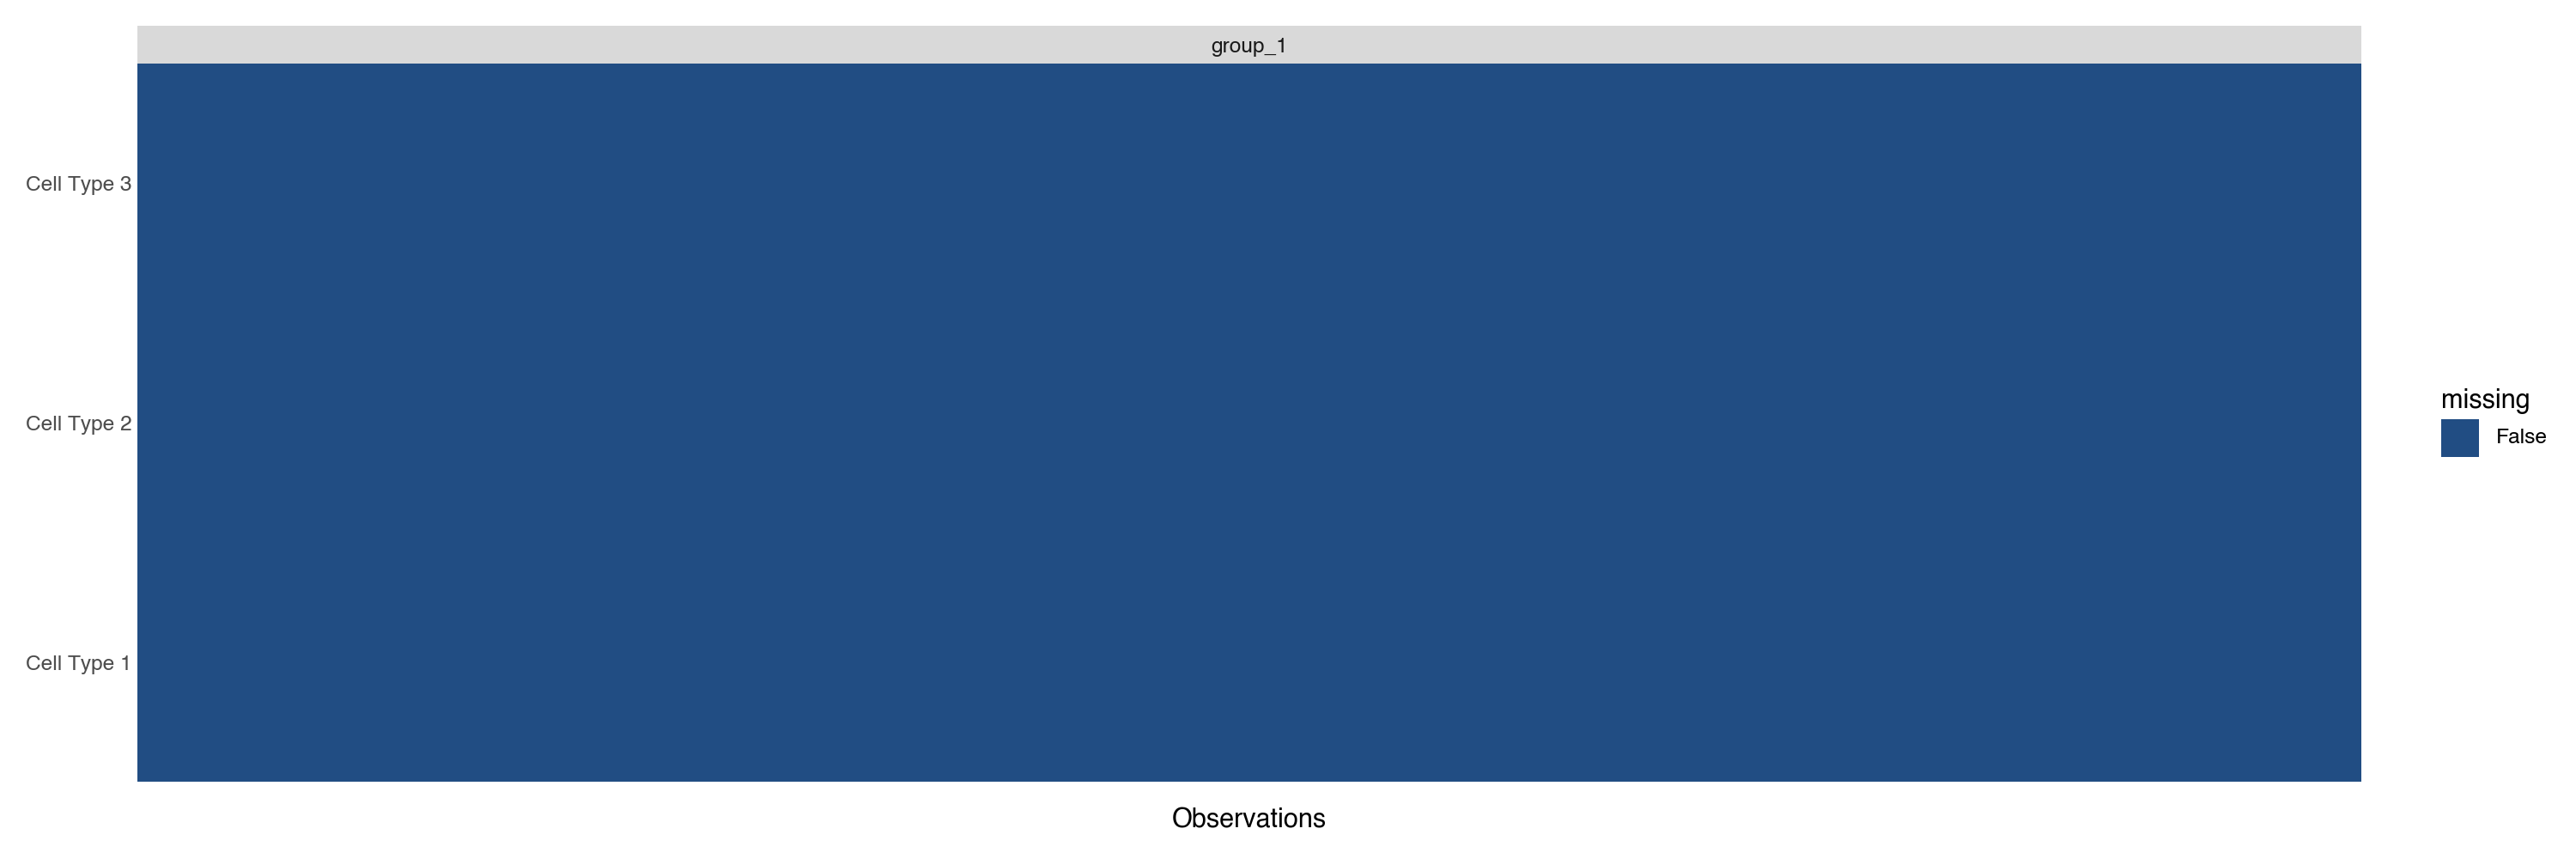

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymor

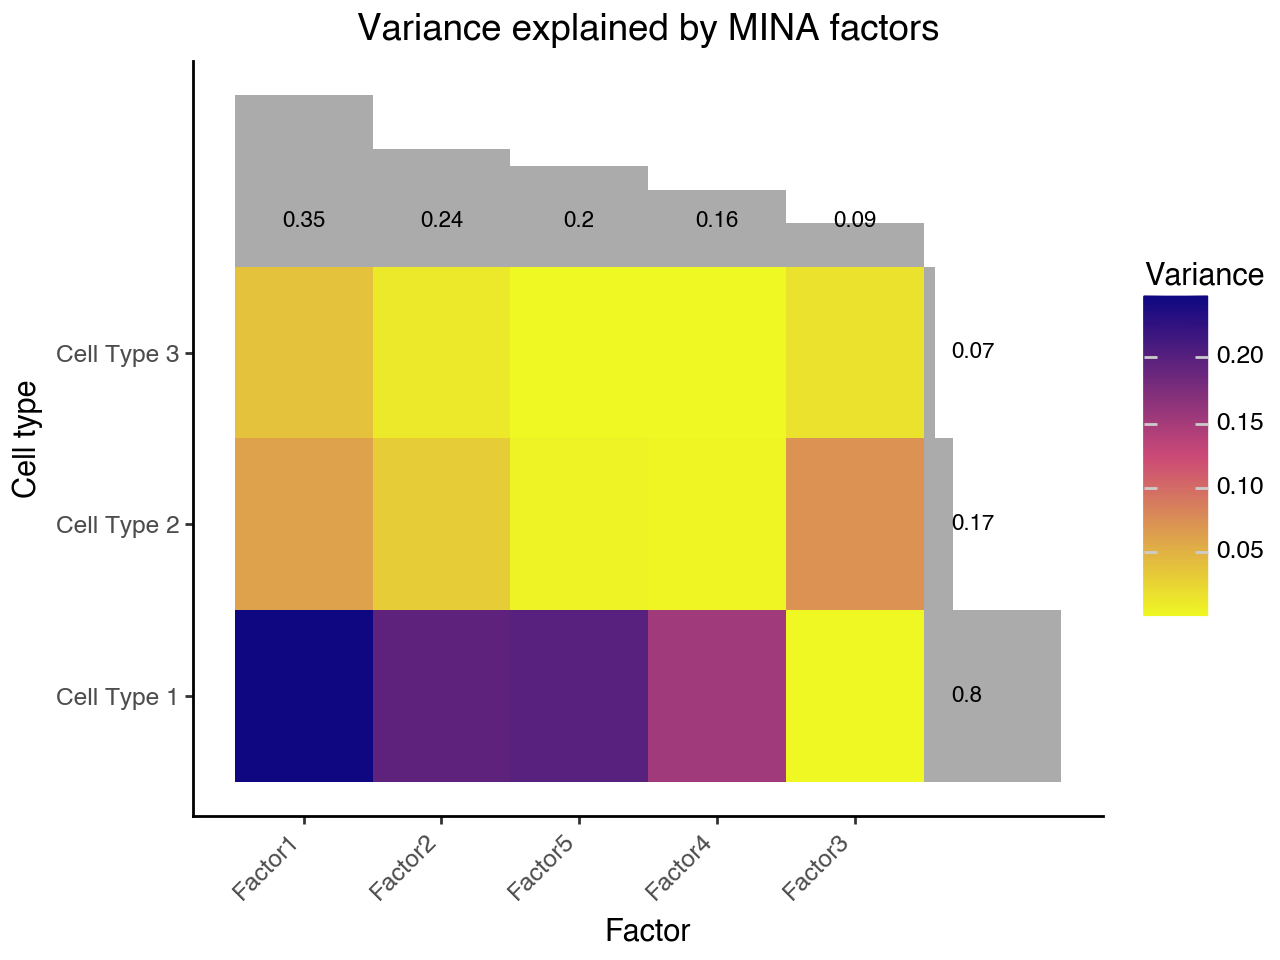

In [3]:
mdata_model = md.MuData(anndata_dict)
model = mf.terms.MofaFlex(n_factors=5, weight_prior="SpikeSlab", init_factors="pca")
model.fit(mdata_model, seed=0, lr=0.01, early_stopper_patience=1000, subset_var=None,
    save_path=False,
    likelihoods="Normal")

amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict, metadata=metadata, model=model
)

variance_df = mina.down.variance_by_view_info(amodel)
mina.pl.plot_variance_by_view(variance_df)

Inspect total variance per factor; factors near zero can be pruned by
lowering `n_factors`.

In [4]:
variance_df.groupby("Factor", observed=True)["Variance"].sum().round(3)

Factor
Factor1    0.349
Factor2    0.240
Factor3    0.088
Factor4    0.155
Factor5    0.204
Name: Variance, dtype: float64

## 6. Sanity-check the reconstruction

A low macro-R² (or a view with near-zero R²) signals that the model does not
capture that view — revisit normalisation, filtering, or the number of
factors.

Macro R2: 0.348


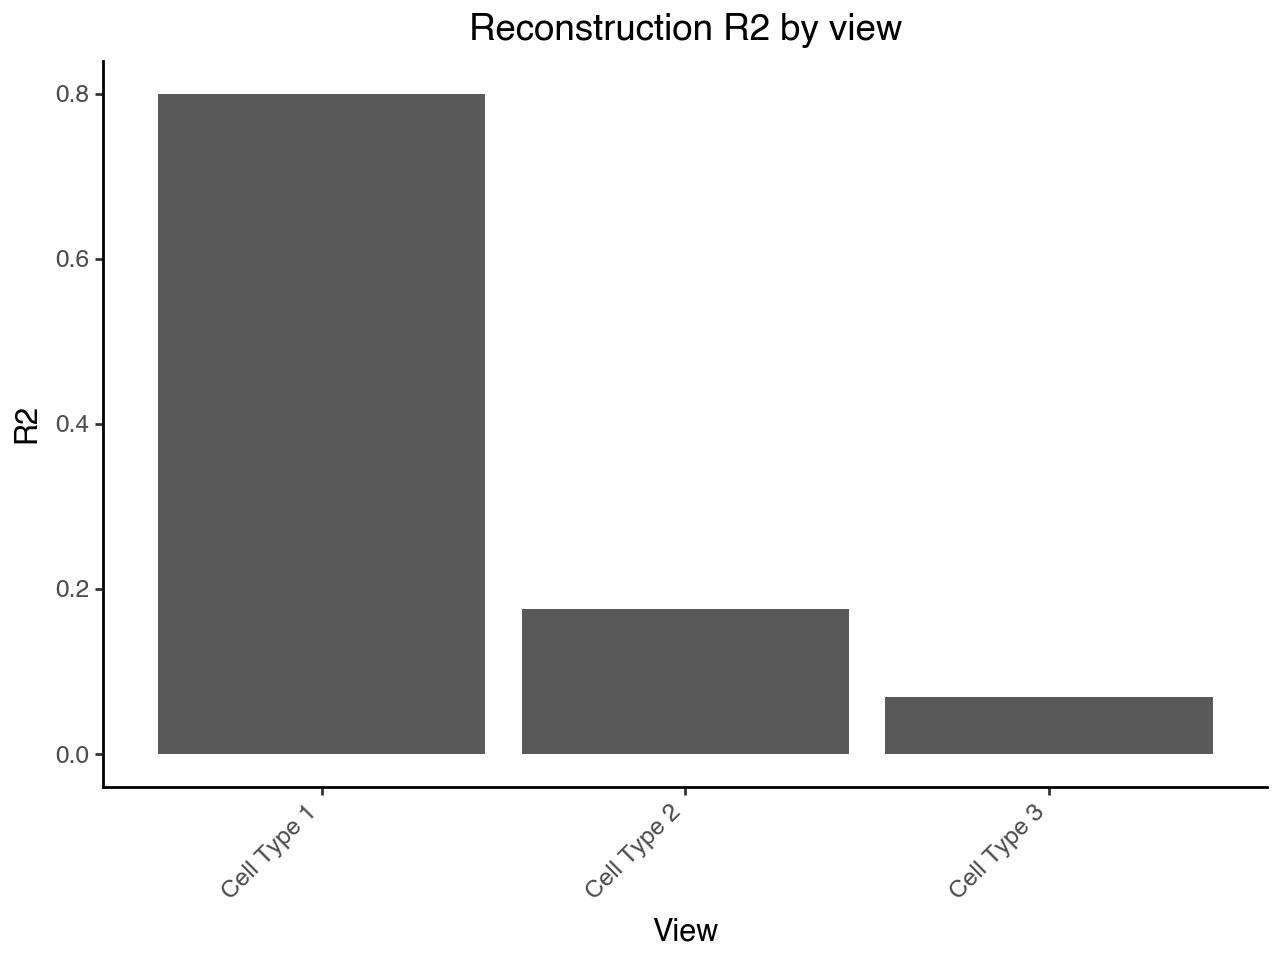

In [5]:
reconstruction = mina.down.reconstruction_info(amodel)
print("Macro R2:", round(reconstruction["macro"]["R2"], 3))
mina.pl.plot_reconstruction(reconstruction["by_view"])

## 7. Interpret factors against covariates

Screen factors against metadata before interpreting loadings. Use Kruskal–Wallis
for categorical covariates, Kendall tau for ordinal ones, and the p-value matrix
to scan many covariates at once. **Identify associated factors programmatically**
rather than hard-coding factor numbers — they change between runs and seeds.

In [6]:
scores = mina.down.factor_scores_info(amodel, obs_keys=["exposure", "batch"])
assoc = mina.down.kruskal_info(scores, group_col="exposure")
top_factor = assoc.iloc[0]["factor"]
assoc

,factor,pvalue,pvalue_bonferroni
0,Factor1,0.000422,0.002110
1,Factor2,0.009591,0.047954
2,Factor3,0.049333,0.246667
3,Factor4,0.159571,0.797855
4,Factor5,0.343834,1.000000


/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/plotnine/positions/position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


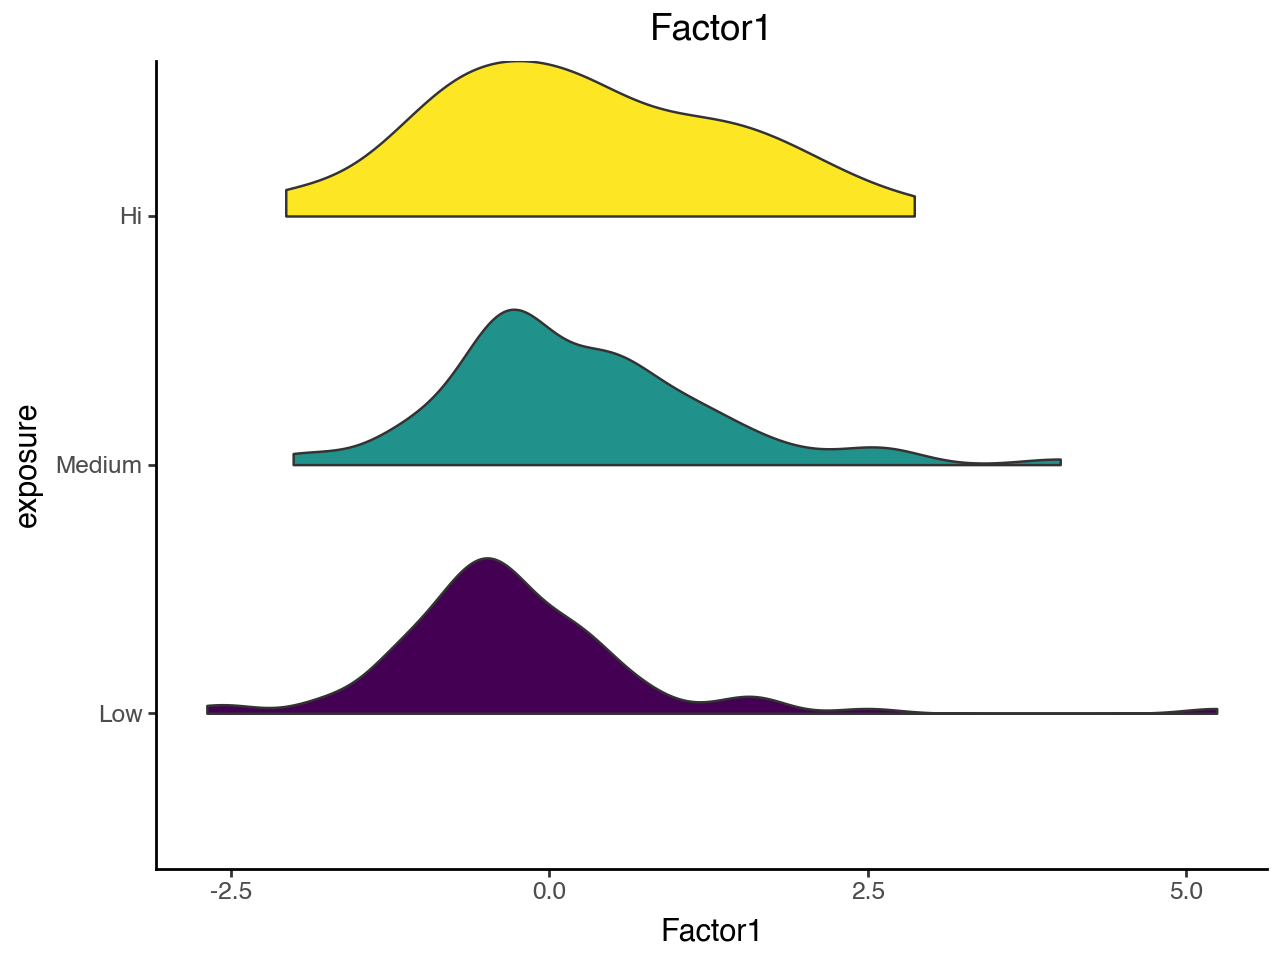

In [7]:
mina.pl.plot_factor_violin(scores, factor=top_factor, group_col="exposure")

## 8. Read out the biology

Inspect the top-loading features of an associated factor (and which views drive
it), then optionally summarise per-view pathway activity with decoupler.

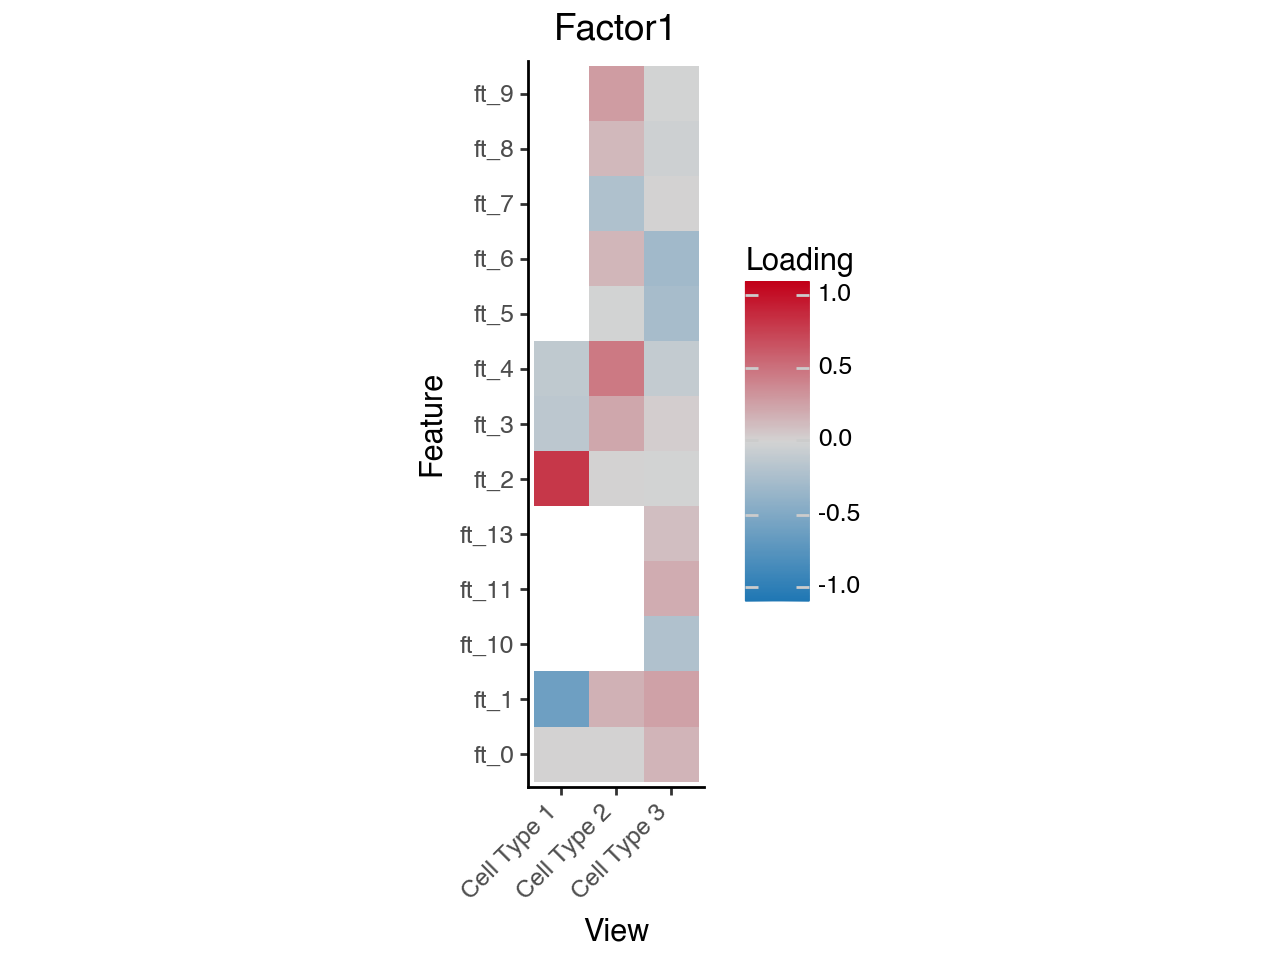

In [8]:
loadings = mina.down.variable_loadings_info(amodel)
mina.pl.plot_top_loadings_heatmap(loadings, factor=top_factor, top_n=20)

**Template** — multicellular coordination network and per-view functional
enrichment for an associated factor (needs ≥ 2 molecular views and, for
enrichment, gene-level features):

```python
networks = mina.down.get_multicell_net(
    test_model=amodel, sel_factor=top_factor,
    standardize=True, drop_na=True, percentile=0.6,
)
mina.pl.plot_mcell_network(networks["negative"], weight_col="cor_estimate",
                           abs_cutoff=0.3, keep_negative=False)

import decoupler as dc
progeny = dc.op.progeny(organism="human", top=1000)
view_loadings = mina.down.split_by_view(
    pd.DataFrame(amodel.varm["gene_loadings"],
                 columns=amodel.uns["gene_loadings_columns"],
                 index=amodel.var_names)
)
pathways = mina.down.run_ulm_per_view(view_dict=view_loadings, net=progeny)
mina.pl.plot_mcell_funcomics(pathways, p_threshold=0.05, top_n=15, use_var=True)
```

## 9. Reproducibility checklist

- Fix every `seed` (decomposition and any permutation-based spatial step).
- Keep raw counts in a layer; record the normalisation mode used.
- Save the model `AnnData` (`amodel.write("model.h5ad")`) so analyses are
  reproducible without refitting.
- Report `n_factors`, the prior, filtering thresholds and the macro-R².